In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, IntSlider
import warnings
warnings.filterwarnings('ignore')

# Set up matplotlib for inline display
%matplotlib inline
plt.rcParams['figure.figsize'] = (16, 5)

In [ ]:
def train_poly_models(X, y, max_degree=8,   
                    learning_rate=0.01, num_iterations=100  #, beta1 = 0.9, beta2 = 0.999, eps = 1e-8
                    ):
    """Train polynomial models of degrees 1 through max_degree, compare"""
    
    # Normalise X
    X_mean, X_std = X.mean(), X.std()
    X_norm = (X - X_mean) / X_std
    num_samples = len(X)

    # Pre-calculate features for all degrees to slice later
    X_poly_full = np.array([[x**i for i in range(max_degree, -1, -1)] for x in X_norm])

    # Storage for train results
    train_results = {
        'final_weights': [],
        'degrees': [],
        'train_loss': []
    }

    print("X_poly_full shape ", X_poly_full.shape)
    
    # Train models of each degree, slicing X_poly_full as needed
    for degree in range(1, max_degree+1):
        print(f"Training degree {degree} model...")

        # Only extract features needed for this model's degree
        # For degree d, we need last (d+1) columns: [X^d, X^(d-1), ..., X^0]
        X_poly = X_poly_full[:, -(degree+1):]  # Shape: (num_samples, degree+1)

        # Initialise weights and Adam values for this degree
        weights = np.zeros(degree + 1) # degree+1 to include degree 0
        # m = np.zeros(degree + 1) # exponentially-updated momentum over previous
        # v = np.zeros(degree + 1) # exponentially-updated squared gradients

        # Training!
        for i in range(num_iterations):
            y_pred = X_poly @ weights

            # Loss
            loss = np.mean((y - y_pred) ** 2)
            gradients = -2 * X_poly.T @ (y - y_pred) / num_samples

            # # Update optimiser variables
            # m = beta1 * m + (1 - beta1) * gradients
            # v = beta2 * v + (1 - beta2) * (gradients ** 2)

            # # Correct for small 
            # m_hat = m / (1 - beta1 ** (i + 1))
            # v_hat = v / (1 - beta2 ** (i + 1))
            # weights -= learning_rate * m_hat / (np.sqrt(v_hat) + eps)
            weights -= learning_rate * gradients # vanilla optimiser step

        # Store train_results after each model training
        train_results['final_weights'].append(weights.copy())
        train_results['degrees'].append(degree)
        train_results['train_loss'].append(loss)

    print("final degrees: ", train_results['degrees'])
    print("final train loss: ", train_results['train_loss'])    
    return train_results, X_mean, X_std

def test_poly_models(X, y,
                     train_X_mean, train_X_std,
                     beta1, beta2, eps,
                     max_degree, final_weights):
    """Test polynomial models of degrees 1 through max_degree"""

    # Normalise X with normalisation from training:
    # Transforms test data to same space
    X_norm = (X - train_X_mean) / train_X_std

    # Pre-calculate features for all degrees to slice later
    X_poly_full = np.array([[x**i for i in range(max_degree, -1, -1)] for x in X_norm])
    # Shape: (num_samples, max_degree+1)

    test_results = {
        'degrees': [],
        'test_loss': []
    }
    
    # Calculate test loss for each model given weights
    for degree in range(1, max_degree+1):
        print(f"Calculating test loss for degree {degree} model...")

        # Only extract features needed for this model's degree
        # For degree d, we need last (d+1) columns: [X^d, X^(d-1), ..., X^0]
        X_poly = X_poly_full[:, -(degree+1):]  # Shape: (num_samples, degree+1)

        # There's 1 set of final weights per degree of model. 
        # Each set of final weights has length [degree], for that model's degree. 
            # Weights[0] — final weights of the smallest-degree MODEL.
            # Weights[0][0] — final weight of the largest-degree TERM.

        # Calculate y-predictions for each X datapoint (row in X_poly) with final weights, indexed by degree
        y_pred = X_poly @ final_weights[degree-1]

        # Loss
        loss = np.mean((y - y_pred) ** 2)
        
        # Store test_results per model degree
        test_results['degrees'].append(degree)
        test_results['test_loss'].append(loss)

    print("final degrees: ", test_results['degrees'])
    print("final test loss: ", test_results['test_loss'])
    
    return test_results

def plot_degree_comparison(X, y, train_results, test_results, train_X_mean, train_X_std, max_degree):
    n_models = max_degree # len(train_results['final_weights'])

    # Create subplots (e.g., 3 rows × 5 columns for 15 models)
    n_cols = 5
    n_rows = (n_models + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4*n_rows))
    axes = axes.flatten()

    # Many X-points for smooth curve plotting
    X_plot = np.linspace(X.min(), X.max(), 200)
    X_plot_norm = (X_plot - train_X_mean) / train_X_std  # Normalize for plotting
    X_poly_plot_full = np.array([[x**i for i in range(n_models, -1, -1)] for x in X_plot_norm])

    for idx in range(n_models):
        degree = len(train_results['final_weights'][idx]) - 1 # for 1 weights vector, num of weights --> degree + 1! (since X^0)
        weights = train_results['final_weights'][idx]
        
        ax = axes[idx]

        # Plot training data
        ax.scatter(X, y, alpha=0.7, s=100, label='Data', color='blue', zorder=3)
        
        # Plot fitted curve
        X_plot_poly = X_poly_plot_full[:, -(degree+1):]  # Extract features for this degree
        y_plot = X_plot_poly @ weights

        ax.plot(X_plot, y_plot, 'r-', linewidth=2.5, label=f'Fit', zorder=1)
        
        # Formatting
        ax.set_title(f'Degree {degree}\nLoss: {train_results["train_loss"][idx]:.2f}', 
                     fontsize=11, fontweight='bold')
        ax.set_xlabel('X')
        ax.set_ylabel('y')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
        
        ax.set_ylim([y.min() - 20, y.max() + 20])
        # ax.set_ylim([-100, 10])  
        
        # # Highlight overfitting cases (degree >= n_samples)
        # if degree >= len(X):
        #     ax.set_facecolor('#fff5f5')  # Light red background
        #     ax.set_title(f'Degree {degree} (OVERFIT!)\nLoss: {train_results["train_loss"][idx]:.2f}', 
        #                 fontsize=11, fontweight='bold', color='red')

    # Hide unused subplots
    for idx in range(n_models, len(axes)):
        axes[idx].axis('off')

    fig.suptitle(f'Training fit, Degrees 1 to {max_degree} over {len(X)} samples (gen from true degree 5)', 
             fontsize=24, fontweight='bold', y=0.995)
    
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(1, 2, figsize=(10, 6))

    # Plot final loss vs degree
    np.set_printoptions(precision=3)
    train_loss_min = min(train_results['train_loss'])
    train_loss_max = max(train_results['train_loss'])
    # print("train_loss array:", train_results['train_loss'])
    print("min loss: ", train_loss_min)
    print("max loss: ", train_loss_max)
    # print("Number of losses:", len(train_results['train_loss']))
    # print("Number of weight sets:", len(train_results['final_weights']))

    ax[0].plot(train_results['degrees'], train_results['train_loss'], 'o-', linewidth=2.5, markersize=8)
    # ax.axvline(x=len(X), color='red', linestyle='--', linewidth=2, 
    #             label=f'n_samples={len(X)}')
    ax[0].set_xlabel('Degree of model fitted', fontsize=12)
    ax[0].set_ylabel('Final loss (MSE)', fontsize=12)
    ax[0].set_yscale('log')
    ax[0].set_ylim([train_loss_min - 20, train_loss_max + 20])
    
    ax[0].set_title('Train loss', fontsize=14, fontweight='bold')
    ax[0].legend()
    ax[0].grid(True, alpha=0.3)

    test_loss_min = min(test_results['test_loss'])
    test_loss_max = max(test_results['test_loss'])
    ax[1].plot(test_results['degrees'], test_results['test_loss'], 'o-', linewidth=2.5, markersize=8)
    # ax.axvline(x=len(X), color='red', linestyle='--', linewidth=2, 
    #             label=f'n_samples={len(X)}')
    # ax[1].set_title('Test loss vs. Degree of model fitted', fontsize=14, fontweight='bold')
    ax[1].set_xlabel('Degree of model fitted', fontsize=12)
    ax[1].set_ylabel('Final loss (MSE)', fontsize=12)
    ax[1].set_yscale('log')
    ax[1].set_ylim([test_loss_min - 20, test_loss_max + 20])
    ax[1].legend()
    
    ax[1].set_title('Test loss', fontsize=14, fontweight='bold')
    # ax.grid(True, alpha=0.3)
    
    plt.show()

before running train_poly, num_iterations: 50000
beginning of train_poly, num_iterations: 50000
X_poly_full shape  (7, 11)
Training degree 1 model...
in train_poly, num_iterations: 50000
Training degree 2 model...
in train_poly, num_iterations: 50000
Training degree 3 model...
in train_poly, num_iterations: 50000
Training degree 4 model...
in train_poly, num_iterations: 50000
Training degree 5 model...
in train_poly, num_iterations: 50000
Training degree 6 model...
in train_poly, num_iterations: 50000
Training degree 7 model...
in train_poly, num_iterations: 50000
Training degree 8 model...
in train_poly, num_iterations: 50000
Training degree 9 model...
in train_poly, num_iterations: 50000
Training degree 10 model...
in train_poly, num_iterations: 50000
final degrees:  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
final train loss:  [np.float64(494.88184929926047), np.float64(38.06183417025655), np.float64(10.244002970165502), np.float64(9.382483357271765), np.float64(6.014176911322616), np.float64(

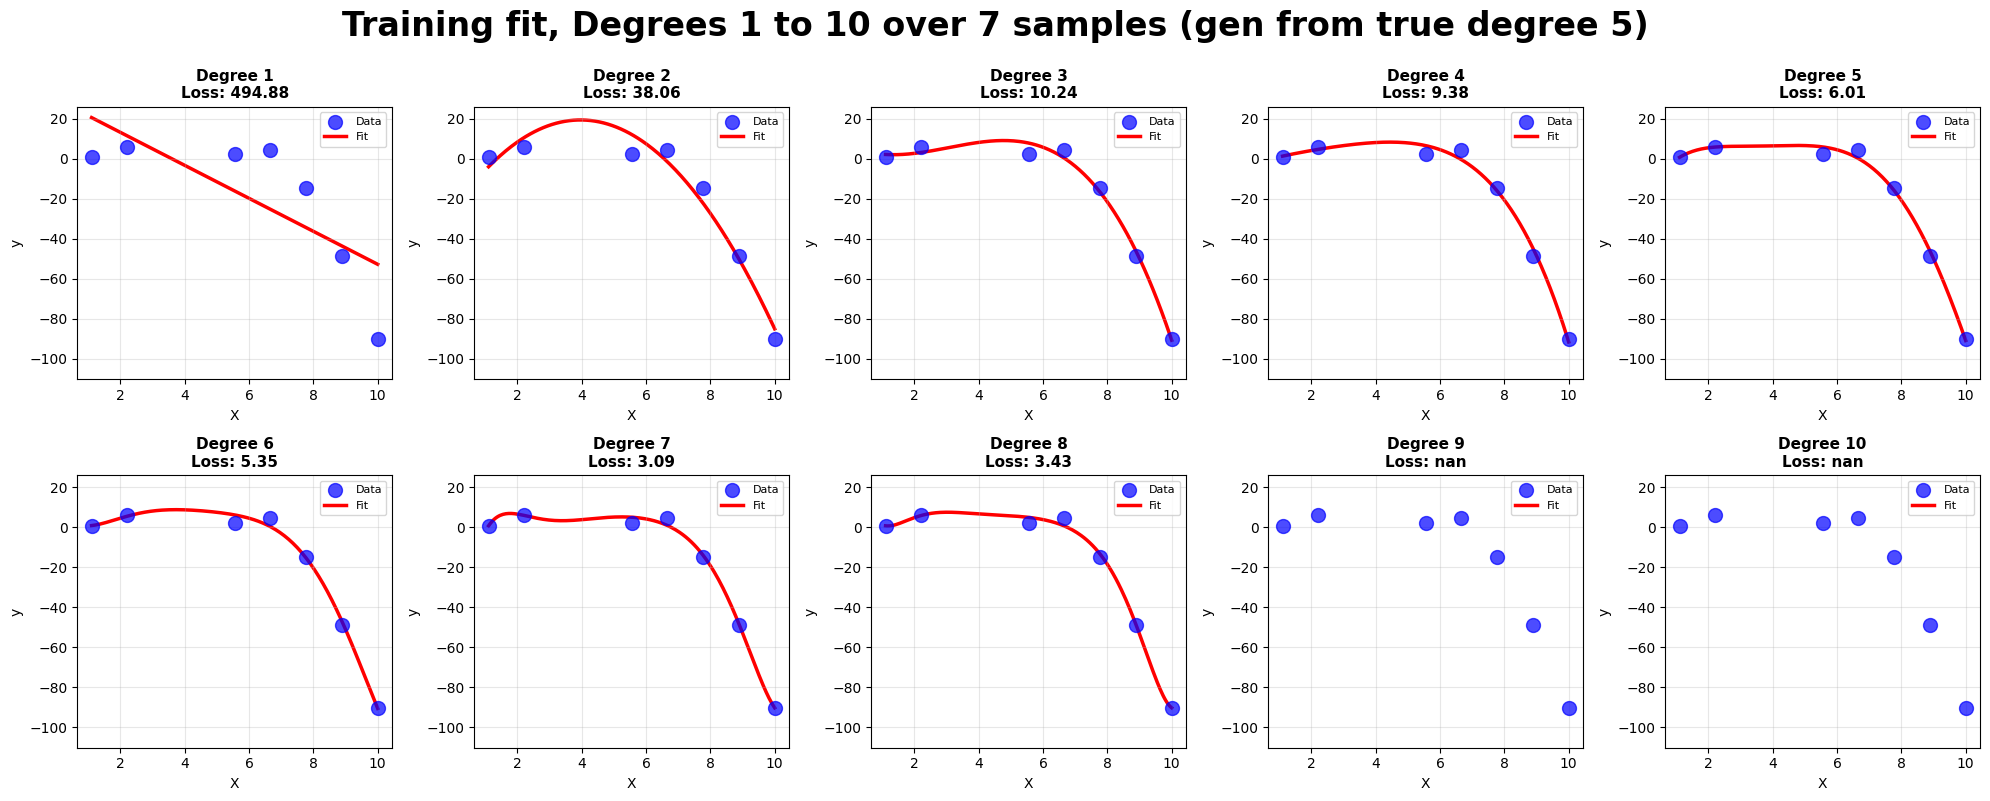

min loss:  3.0890637070391698
max loss:  494.88184929926047


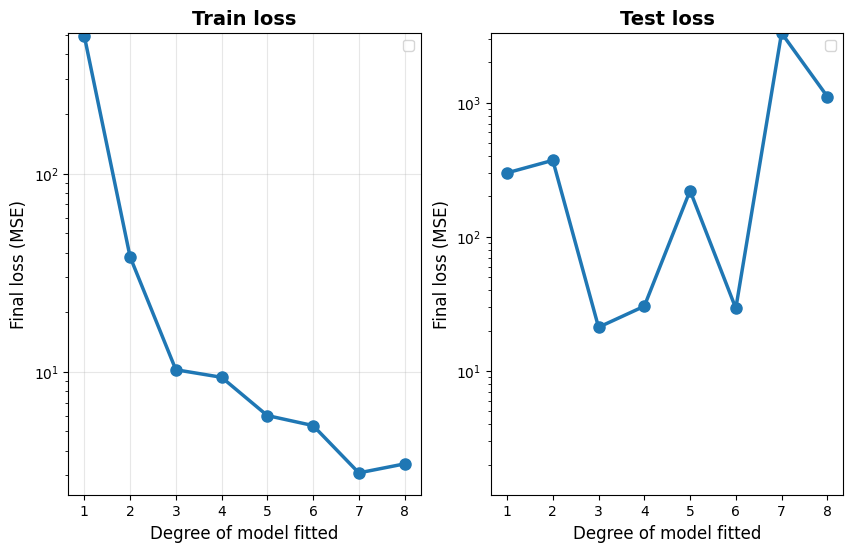

In [39]:
 # Hyperparameters
max_degree = 10
noisiness = 5
learning_rate = 0.001
num_iterations = 50000
num_samples = 10
test_ratio = 0.3

# Adam hyperparameters
beta1 = 0.9
beta2 = 0.999
eps = 1e-8 # prevents divide by zero errors

# Generate data to draw from with some noise
np.random.seed(42)
# X = np.random.uniform(0, 10, num_samples) # random of num_samples points from 0 to 10
X = np.linspace(0, 10, num_samples) # array of num_samples points from 0 to 10
true_rel = -0.001*X**5 + 0.002*X**4 - 0.08*X**3 + 0.7*X**2 - 0.4*X + 1
y = true_rel + np.random.randn(num_samples) * noisiness

# Shuffle and split on random indices
indices = np.random.permutation(num_samples)
split = int(num_samples * (1 - test_ratio))
X_train, X_test = X[indices[:split]], X[indices[split:]]
y_train, y_test = y[indices[:split]], y[indices[split:]]

# Train models
train_results, train_X_mean, train_X_std = train_poly_models(X_train, y_train, max_degree,
                                                             learning_rate,
                                                            #  beta1, beta2, eps,
                                                             num_iterations)

# Test models
test_results = test_poly_models(X_test, y_test,
                                train_X_mean, train_X_std,
                                beta1, beta2, eps,
                                max_degree, train_results['final_weights'])

# Visualise
plot_degree_comparison(X_train, y_train, train_results, test_results, train_X_mean, train_X_std, max_degree)
# plot_degree_comparison(X, y, results, X_mean, X_std, max_degree)